In [11]:
# Step 1: Imports and reproducibility
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make results reproducible so everyone sees the same numbers
np.random.seed(42)

## Rolling Z-Score

In [12]:
# Step 2: Create a drifting time series with one anomaly

baseline = 100      # starting level
drift = 0.5         # slow upward drift per time step
noise = 10          # random noise around the trend
n_points = 100      # total number of data points

data_points = []

for i in range(n_points):
    if i == 70:
        # Inject a clear anomaly at index 70
        data_points.append(250)
    else:
        # Normal point: baseline + drift * time + random noise
        point = baseline + (i * drift) + np.random.uniform(-noise, noise)
        data_points.append(point)

# Create a pandas Series from the list
ts_data = pd.Series(data_points)

# Show the first few values
ts_data.head()

0     97.490802
1    109.514286
2    105.639879
3    103.473170
4     95.120373
dtype: float64

**Lưu ý về `shift(1)` trong Rolling Z-Score:**  

Khi tính Z-score cho điểm hiện tại \(x_t\), baseline nên được xây dựng từ các điểm dữ liệu **trước đó**, không bao gồm chính \(x_t\). Nếu dùng trực tiếp `ts_data.rolling(...).mean()`, rolling window sẽ chứa luôn điểm hiện tại. Khi điểm hiện tại là anomaly, nó sẽ làm lệch rolling mean và làm phình rolling std, khiến Z-score bị nhỏ đi và detector có thể bỏ sót cảnh báo.  


In [13]:
# Step 3: Compute Rolling Z-Score

window_size = 5     # Look at the last 5 data points
threshold = 3.0     # Alert if Z-score > 3 or < -3

# Calculate rolling mean and rolling standard deviation
rolling_mean = ts_data.shift(1).rolling(window=3).mean()
rolling_std = ts_data.shift(1).rolling(window=3).std()

# Calculate Z-score for each data point
z_scores = (ts_data - rolling_mean) / rolling_std

# Show the first few Z-score values
z_scores.head(10)

0          NaN
1          NaN
2          NaN
3    -0.120875
4    -3.623153
5    -1.042598
6    -0.834474
7    21.396646
8     0.630781
9     0.582085
dtype: float64

In [14]:
# Step 4: Detect anomalies

anomalies = ts_data[abs(z_scores) > threshold]

print("--- Checking for Anomalies ---")

if anomalies.empty:
    print("No anomalies detected.")
else:
    for i, value in anomalies.items():
        print(f"ALERT! Outlier detected at index {i}:")
        print(f"  Value: {value}")
        print(f"  Z-Score: {z_scores[i]:.2f} (Threshold: ±{threshold})")
        print("-" * 30)

--- Checking for Anomalies ---
ALERT! Outlier detected at index 4:
  Value: 95.12037280884873
  Z-Score: -3.62 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 7:
  Value: 110.8235229154987
  Z-Score: 21.40 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 10:
  Value: 95.41168988591605
  Z-Score: -5.44 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 16:
  Value: 104.08484485919075
  Z-Score: 11.53 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 17:
  Value: 108.99512863264476
  Z-Score: 3.79 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 25:
  Value: 118.20351922786027
  Z-Score: 4.33 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 36:
  Value: 114.09227538346741
  Z-Score: -8.18 (Threshold: ±3.0)
------------------------------
ALERT! Outlier detected at index 43:
  Value: 129.686408041

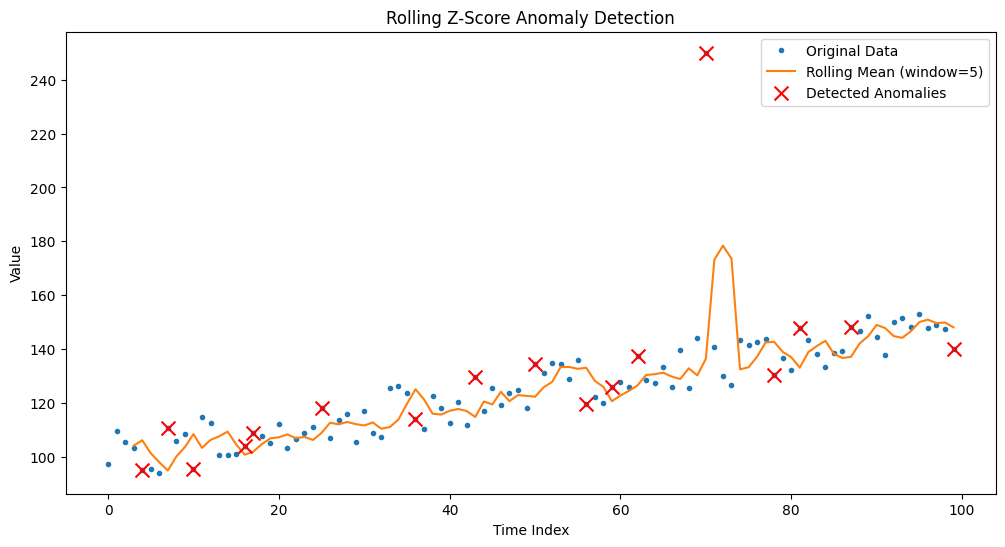

In [15]:
# Step 5: Plot original data, rolling mean, and detected anomalies

plt.figure(figsize=(12, 6))

# Original data
plt.plot(
    ts_data,
    label='Original Data',
    marker='.',
    linestyle='none'
)

# Rolling mean as baseline
plt.plot(
    rolling_mean,
    label=f'Rolling Mean (window={window_size})',
    linestyle='-'
)

# Detected anomalies
plt.scatter(
    anomalies.index,
    anomalies.values,
    label='Detected Anomalies',
    marker='x',
    s=100,
    color='red',
    zorder=5
)

plt.title('Rolling Z-Score Anomaly Detection')
plt.xlabel('Time Index')
plt.ylabel('Value')
plt.legend()
plt.show()

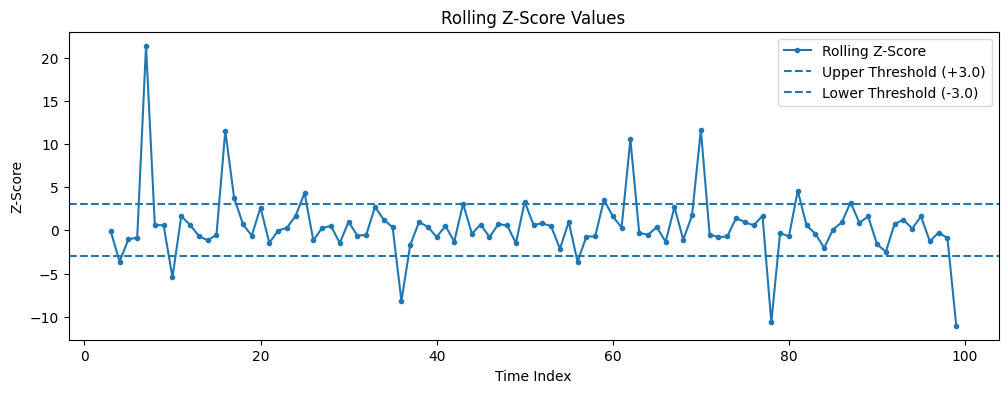

In [16]:
# Step 6: Plot Z-scores and threshold lines

plt.figure(figsize=(12, 4))

# Z-score line
plt.plot(
    z_scores,
    label='Rolling Z-Score',
    marker='.',
    linestyle='-'
)

# Positive and negative thresholds
plt.axhline(
    y=threshold,
    label=f'Upper Threshold (+{threshold})',
    linestyle='--'
)

plt.axhline(
    y=-threshold,
    label=f'Lower Threshold (-{threshold})',
    linestyle='--'
)

plt.title('Rolling Z-Score Values')
plt.xlabel('Time Index')
plt.ylabel('Z-Score')
plt.legend()
plt.show()

## EWMA (Exponentially Weighted Moving Average)s

In [17]:
# Step 2: Create a drifting time series with one anomaly

baseline = 100      # starting level
drift = 0.5         # slow upward drift per time step
noise = 10          # random noise around the trend
n_points = 100      # total number of data points

data_points = []

for i in range(n_points):
    if i == 70:
        # Inject a clear anomaly at index 70
        data_points.append(250)
    else:
        # Normal point: baseline + drift * time + random noise
        point = baseline + (i * drift) + np.random.uniform(-noise, noise)
        data_points.append(point)

# Create a pandas Series from the list
ts_data = pd.Series(data_points)

# Show the first few values
ts_data.head()

0     92.157829
1     91.128584
2    103.728208
3     97.787120
4    102.171414
dtype: float64

In [18]:
# Step 3: Compute EWMA

alpha = 0.2

ewma = ts_data.ewm(alpha=alpha, adjust=False).mean()

# Show the first few EWMA values
ewma.head()

0    92.157829
1    91.951980
2    94.307225
3    95.003204
4    96.436846
dtype: float64

In [19]:
# Step 4: Compute global 3-sigma control limits

# Residuals: how far each point is from the EWMA line
residuals = ts_data - ewma

# Standard deviation of the residuals
sigma = residuals.std()

# Number of standard deviations for the control band (3-sigma rule)
k = 3

# Upper and Lower Control Limits
UCL = ewma + k * sigma
LCL = ewma - k * sigma

# Show the first few control limit values
UCL.head(), LCL.head()

(0    125.377443
 1    125.171594
 2    127.526840
 3    128.222819
 4    129.656461
 dtype: float64,
 0    58.938214
 1    58.732365
 2    61.087610
 3    61.783589
 4    63.217231
 dtype: float64)

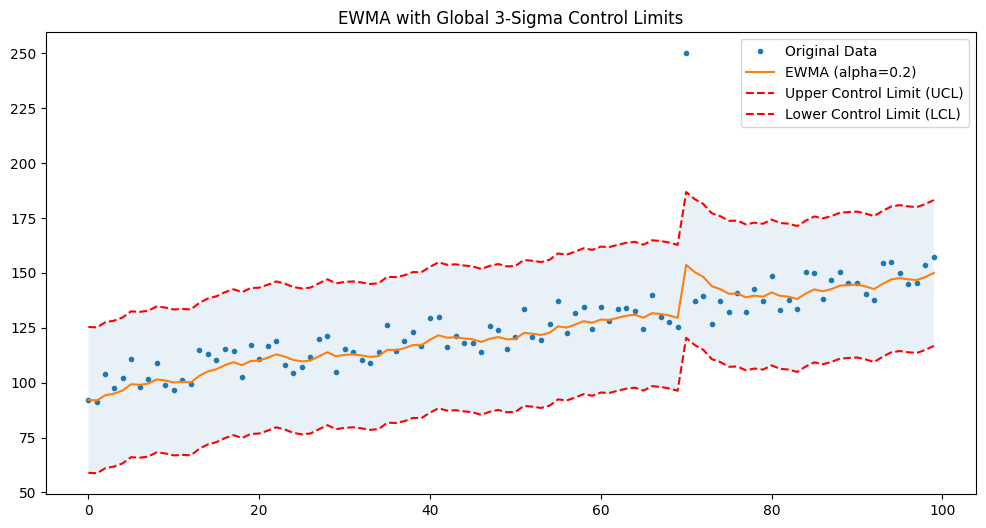

In [20]:
# Step 5: Plot the data, EWMA, and global control limits

plt.figure(figsize=(12, 6))

# Original data as points
plt.plot(ts_data, label='Original Data', marker='.', linestyle='none')

# EWMA as a smooth line
plt.plot(ewma, label='EWMA (alpha=0.2)', linestyle='-')

# Control Limits
plt.plot(UCL, label='Upper Control Limit (UCL)', linestyle='--', color='red')
plt.plot(LCL, label='Lower Control Limit (LCL)', linestyle='--', color='red')

# Shade the normal region between LCL and UCL
plt.fill_between(ts_data.index, LCL, UCL, alpha=0.1)

plt.title('EWMA with Global 3-Sigma Control Limits')
plt.legend()
plt.show()